# Прогноз до 2030 года

**Проект:** Анализ международной мобильности российских студентов (2000–2024).

## Задачи
- Для выбранных стран проанализировать фактическую динамику мобильности и сглаженный тренд.
- Построить модели линейной регрессии для оценки тренда мобильности до 2030 года.
- Оценить качество построенных моделей.

## Выбор стран
Для прогнозирования числа российских студентов за рубежом до 2030 г. выбраны три страны, представляющие разные типы динамики студенческой мобильности:
- Германия,
- Великобритания,
- Турция.

## Динамика мобильности

Для предварительной визуальной оценки тренда построены линейные графики по фактическим данным. По Германии данные доступны за 2013–2024 гг., поэтому графики показывают динамику только для этого периода.

In [1]:
import pandas as pd

df=pd.read_excel('../data/processed/countries_sel_2000_2024.xlsx')
df.head()

,Страна,Год,Число студентов из РФ,Регион,Тип направления
0,Armenia,2003,290,Asia,Post-Soviet space
1,Armenia,2004,662,Asia,Post-Soviet space
2,Armenia,2005,477,Asia,Post-Soviet space
3,Armenia,2006,680,Asia,Post-Soviet space
4,Armenia,2007,828,Asia,Post-Soviet space


In [2]:
df=df[df['Страна'].isin(['Germany', 'United Kingdom', 'Türkiye'])].reset_index(drop=True)
df=df.drop(['Регион', 'Тип направления'], axis=1).reset_index(drop=True)

df.head()

,Страна,Год,Число студентов из РФ
0,Germany,2013,9480
1,Germany,2014,9668
2,Germany,2015,9953
3,Germany,2016,9711
4,Germany,2017,9620


In [3]:
df.groupby('Страна')['Год'].agg(['min', 'max', 'count'])

,min,max,count
Страна,,,
Germany,2013,2024,12
Türkiye,2000,2023,24
United Kingdom,2000,2023,24


In [4]:
df_pivot=df.pivot(index='Год',
                  columns='Страна',
                  values='Число студентов из РФ')
df_pivot.head()

Страна,Germany,Türkiye,United Kingdom
Год,,,
2000,NaN,1004.0,1058.0
2001,NaN,924.0,1370.0
2002,NaN,846.0,1461.0
2003,NaN,720.0,1601.0
2004,NaN,662.0,1878.0


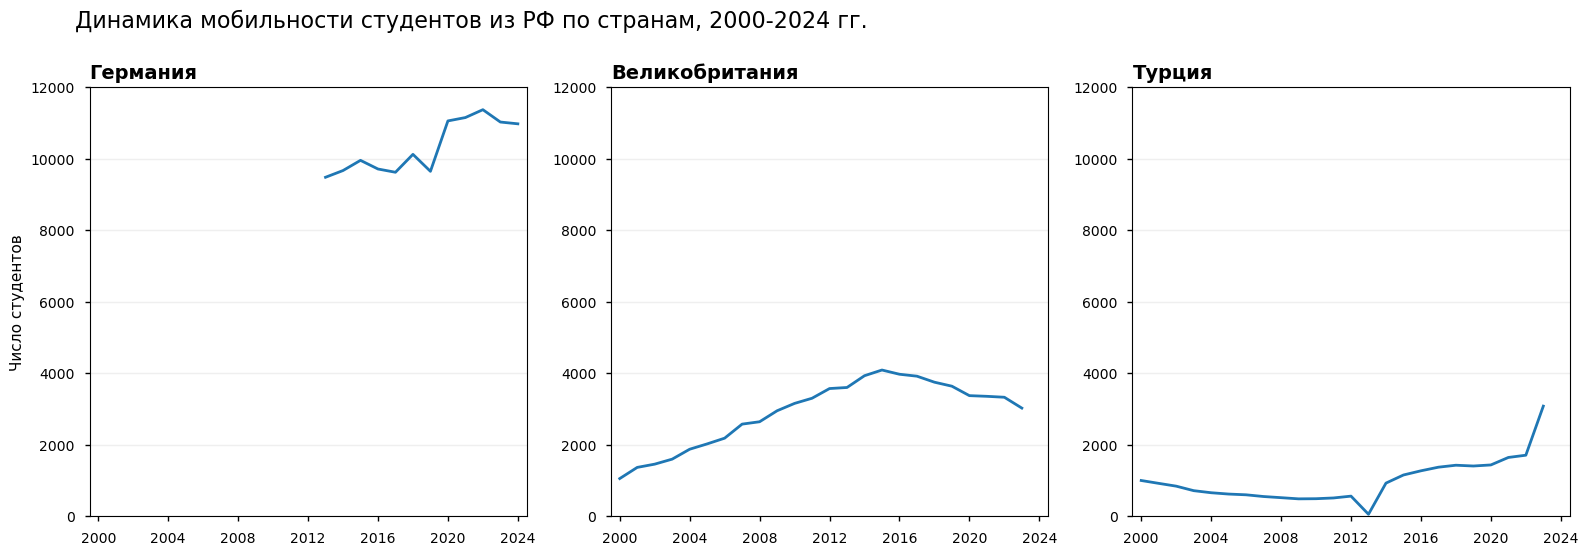

In [5]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

mpl.style.use('seaborn-v0_8-notebook')

fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(16, 5.5))

# Германия
sns.lineplot(data=df_pivot,
             x='Год',
             y='Germany',
             linewidth=2,
            ax=ax1)

ax1.set_title('Германия', fontsize=14, fontweight='bold', loc='left')
ax1.set_xlabel('')
ax1.set_ylabel('Число студентов')
ax1.set_xticks(range(2000, 2025, 4))
ax1.set_xticklabels(range(2000, 2025, 4))
ax1.set_xlim(1999.5, 2024.5)
ax1.set_ylim(0,12000)
ax1.grid(True, axis='y', alpha=0.2)

# Великобритания
sns.lineplot(data=df_pivot,
             x='Год',
             y='United Kingdom',
             linewidth=2,
            ax=ax2)

ax2.set_title('Великобритания', fontsize=14, fontweight='bold', loc='left')
ax2.set_xlabel('')
ax2.set_ylabel('')
ax2.set_xticks(range(2000, 2025, 4))
ax2.set_xticklabels(range(2000, 2025, 4))
ax2.set_xlim(1999.5, 2024.5)
ax2.set_ylim(0,12000)
ax2.grid(True, axis='y', alpha=0.2)

# Турция
sns.lineplot(data=df_pivot,
             x='Год',
             y='Türkiye',
             linewidth=2,
            ax=ax3)

ax3.set_title('Турция', fontsize=14, fontweight='bold', loc='left')
ax3.set_xlabel('')
ax3.set_ylabel('')
ax3.set_xticks(range(2000, 2025, 4))
ax3.set_xlim(1999.5, 2024.5)
ax3.set_ylim(0,12000)
ax3.grid(True, axis='y', alpha=0.2)

fig.suptitle('Динамика мобильности студентов из РФ по странам, 2000-2024 гг.', 
             size=16, x=0.05, ha='left', y=1.001)

plt.tight_layout()

plt.savefig('../visuals/05_student_mobility_deu_gbr_tur.png', dpi=150, bbox_inches='tight')

plt.show()

## Сглаженный тренд

Чтобы нагляднее показать тренды мобильности, рассчитано скользящее среднее числа российских студентов по странам за три года, и построены графики сглаженного тренда.

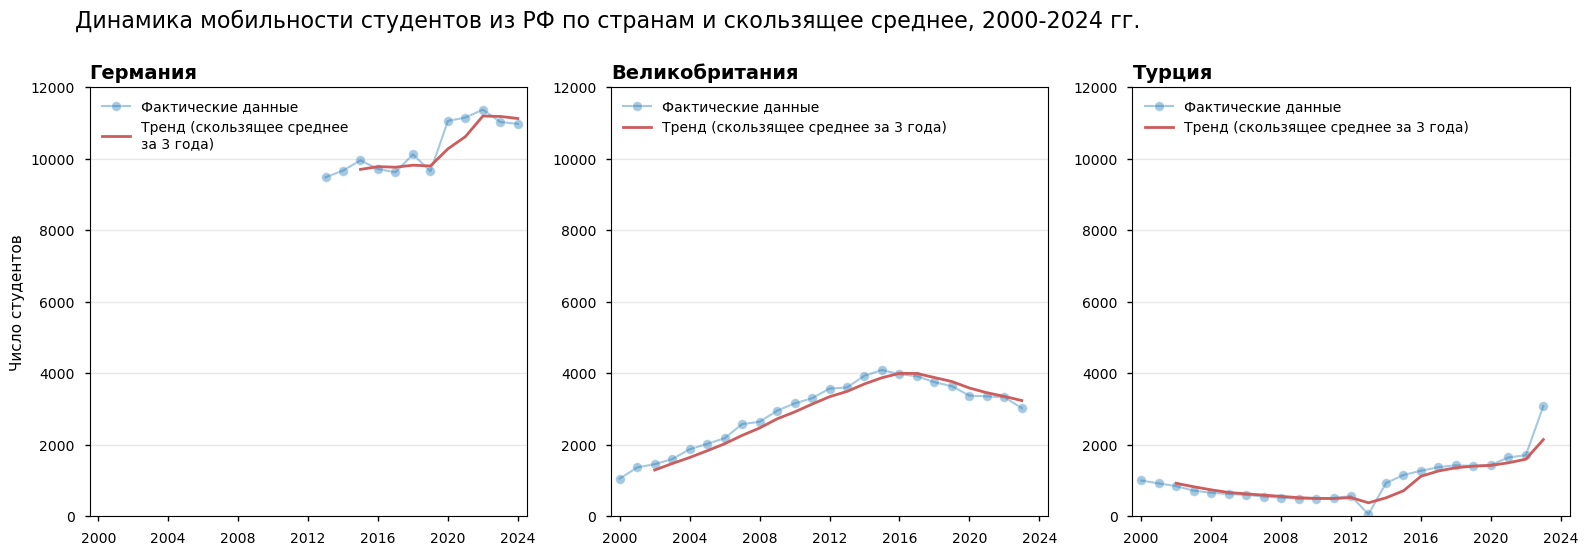

In [6]:
df_pivot=df_pivot.reset_index()

# Скользящее среднее по Германии
deu=df_pivot[['Год', 'Germany']].dropna().copy()
deu['Тренд_3_года']=deu['Germany'].rolling(window=3).mean()

fig, (ax1, ax2, ax3)=plt.subplots(1,3, figsize=(16, 5.5))

sns.lineplot(data=deu,
             x='Год', 
             y='Germany', 
             marker='o', 
             alpha=0.4,
             linewidth=1.5,
             label='Фактические данные',
             ax=ax1)

sns.lineplot(data=deu,
             x='Год', 
             y='Тренд_3_года', 
             linewidth=2, 
             label='Тренд (скользящее среднее\nза 3 года)',
             color='indianred',
             ax=ax1)

ax1.set_title('Германия', fontweight='bold', fontsize=14, loc='left')
ax1.set_xlabel('')
ax1.set_ylabel('Число студентов')
ax1.set_xlim(1999.5, 2024.5)
ax1.set_ylim(0,12000)
ax1.set_xticks(range(2000,2025,4))
ax1.legend(loc='upper left', frameon=False)
ax1.grid(axis='y', alpha=0.3)

# Скользящее среднее по Великобритании
gbr=df_pivot[['Год', 'United Kingdom']].dropna().copy()
gbr['Тренд_3_года'] = gbr['United Kingdom'].rolling(window=3).mean()

sns.lineplot(data=gbr,
             x='Год', 
             y='United Kingdom', 
             marker='o', 
             alpha=0.4,
             linewidth=1.5,
             label='Фактические данные',
             ax=ax2)

sns.lineplot(data=gbr,
             x='Год', 
             y='Тренд_3_года', 
             linewidth=2, 
             label='Тренд (скользящее среднее за 3 года)',
             color='indianred',
             ax=ax2)

ax2.set_title('Великобритания', fontweight='bold', fontsize=14, loc='left')
ax2.set_xlabel('')
ax2.set_ylabel('')
ax2.set_xlim(1999.5, 2024.5)
ax2.set_ylim(0,12000)
ax2.set_xticks(range(2000,2025,4))
ax2.legend(loc='upper left', frameon=False)
ax2.grid(axis='y', alpha=0.3)

# Скользящее среднее по Турции
tur=df_pivot[['Год', 'Türkiye']].dropna().copy()
tur['Тренд_3_года'] = tur['Türkiye'].rolling(window=3).mean()

sns.lineplot(data=tur,
             x='Год', 
             y='Türkiye', 
             marker='o', 
             alpha=0.4,
             linewidth=1.5,
             label='Фактические данные',
             ax=ax3)

sns.lineplot(data=tur,
             x='Год', 
             y='Тренд_3_года', 
             linewidth=2, 
             label='Тренд (скользящее среднее за 3 года)',
             color='indianred',
             ax=ax3)

ax3.set_title('Турция', fontweight='bold', fontsize=14, loc='left')
ax3.set_xlabel('')
ax3.set_ylabel('')
ax3.set_xlim(1999.5, 2024.5)
ax3.set_ylim(0,12000)
ax3.set_xticks(range(2000,2025,4))
ax3.legend(loc='upper left', frameon=False)
ax3.grid(axis='y', alpha=0.3)

fig.suptitle('Динамика мобильности студентов из РФ по странам и скользящее среднее, 2000-2024 гг.', 
             size=16, x=0.05, ha='left', y=1.001)

plt.tight_layout()

plt.savefig('../visuals/05_rolling_mean_student_mobility_deu_gbr_tur.png', dpi=150, bbox_inches='tight')

plt.show()

## Модели линейной регрессии

Для прогнозирования тренда мобильности по странам построены простые модели линейной регрессии, где в качестве независимой переменной выступает время. Такая модель позволяет оценить общий тренд на основе исторических данных и экстраполировать его на ближайшие годы.

## Германия

In [7]:
# Подготовка данных по Германии

df_deu=df_pivot.drop(['Türkiye', 'United Kingdom'], axis=1).dropna().reset_index(drop=True)
df_deu['time']=df_deu['Год']-df_deu['Год'].min()
df_deu

Страна,Год,Germany,time
0,2013,9480.0,0
1,2014,9668.0,1
2,2015,9953.0,2
3,2016,9711.0,3
4,2017,9620.0,4
5,2018,10121.0,5
6,2019,9646.0,6
7,2020,11055.0,7
8,2021,11149.0,8
9,2022,11369.0,9


In [8]:
# Выделение матрицы объект-признак и целевой переменной

X_deu=df_deu[['time']]
y_deu=df_deu['Germany']

In [9]:
# Разделение выборки на тренировочную и тестовую части

deu_train=int(len(df_deu)*0.8)
deu_test=len(df_deu)-deu_train

# Первые 80% данных на обучение модели
X_deu_train=df_deu[['time']][:deu_train]
y_deu_train=df_deu['Germany'][:deu_train]

# Другие 20% данных на тестирование модели
X_deu_test=df_deu[['time']][deu_train:]
y_deu_test=df_deu['Germany'][deu_train:]

print('ГЕРМАНИЯ', 
      f'\nДанные для обучения модели: {deu_train}', 
      f'\nТестовые данные: {deu_test}')

ГЕРМАНИЯ 
Данные для обучения модели: 9 
Тестовые данные: 3


In [10]:
# Обучение модели на тренировочных данных

from sklearn.linear_model import LinearRegression

model_deu=LinearRegression()
model_deu.fit(X_deu_train, y_deu_train)

LinearRegression()

In [11]:
# Проверка модели на тестовых данных

deu_test_pred=model_deu.predict(X_deu_test)
deu_test_pred

array([10930.86111111, 11108.07777778, 11285.29444444])

In [12]:
# Фактические данные (тестовая часть)

y_deu_test

9     11369.0
10    11024.0
11    10974.0
Name: Germany, dtype: float64

In [13]:
# Проверка качества модели

# Вычисление метрики MSE на тестовых данных
from sklearn.metrics import mean_squared_error

print(f'MSE: {mean_squared_error(y_deu_test, deu_test_pred)}')

# Вычисление метрики RMSE на тестовых данных (средняя ошибка прогноза)
print(f'RMSE: {mean_squared_error(y_deu_test, deu_test_pred) ** 0.5}')

# Вычисление ежегодного прироста и базового уровня
print(f'Ежегодный прирост: {model_deu.coef_[0]}',
      f'\nБазовый уровень: {model_deu.intercept_}')

MSE: 98646.32993827133
RMSE: 314.0801329888144
Ежегодный прирост: 177.21666666666667 
Базовый уровень: 9335.91111111111


In [14]:
# Прогноз тренда мобильности для Германии с 2025 по 2030 год

last_time_deu=df_deu['time'].max()
future_deu=pd.DataFrame({'Год':[2025,2026,2027,2028,2029,2030],
                         'time':range(last_time_deu + 1, last_time_deu + 7)})

X_deu_future=future_deu[['time']]
Y_deu_future=model_deu.predict(X_deu_future)
Y_deu_future

array([11462.51111111, 11639.72777778, 11816.94444444, 11994.16111111,
       12171.37777778, 12348.59444444])

In [15]:
# Таблица прогноза для Германии

forecast_deu=future_deu.drop('time', axis=1)
forecast_deu['Прогноз']=Y_deu_future.round().astype(int)
forecast_deu

,Год,Прогноз
0,2025,11463
1,2026,11640
2,2027,11817
3,2028,11994
4,2029,12171
5,2030,12349


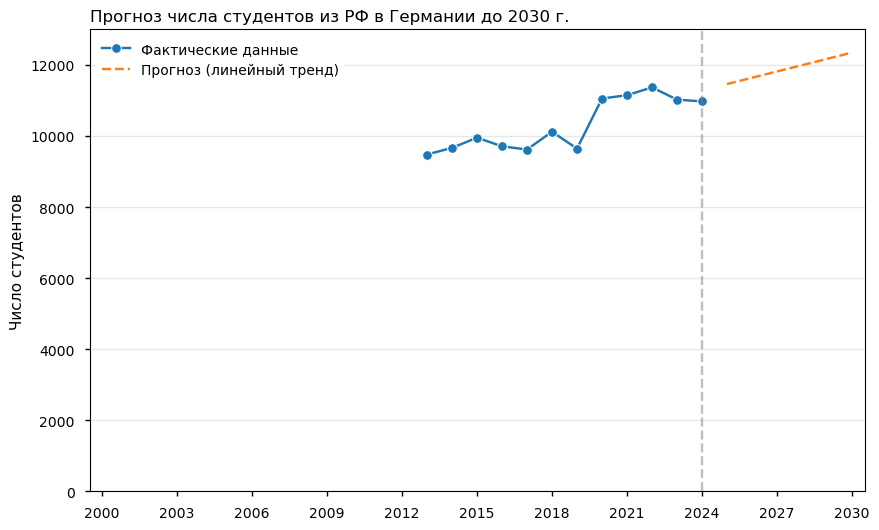

In [16]:
# Визуализация фактической и прогнозной динамики числа российских студентов в Германии

fig, ax=plt.subplots(figsize=(10,6))

sns.lineplot(data=df_deu,
             x='Год', 
             y='Germany',
             marker='o', 
             label='Фактические данные',
            ax=ax)

sns.lineplot(data=forecast_deu,
             x='Год',
             y='Прогноз',
             linestyle='--',
             label='Прогноз (линейный тренд)',
            ax=ax)

ax.set_xlabel('')
ax.set_ylabel('Число студентов')
ax.set_title('Прогноз числа студентов из РФ в Германии до 2030 г.', loc='left')
ax.set_xlim(1999.5, 2030.5)
ax.set_ylim(0,13000)
ax.set_xticks(range(2000,2031,3))
ax.legend(loc='upper left', framealpha=1, edgecolor='white')
ax.axvline(2024, linestyle='--', color='gray', alpha=0.5)
ax.grid(axis='y', alpha=0.3)

plt.savefig('../visuals/05_forecast_deu.png', dpi=150, bbox_inches='tight')

plt.show()

## Великобритания

In [17]:
# Подготовка данных по Великобритании

df_gbr=df_pivot.drop(['Türkiye', 'Germany'], axis=1).dropna().reset_index(drop=True)
df_gbr['time']=df_gbr['Год']-df_gbr['Год'].min()
df_gbr.head()

Страна,Год,United Kingdom,time
0,2000,1058.0,0
1,2001,1370.0,1
2,2002,1461.0,2
3,2003,1601.0,3
4,2004,1878.0,4


In [18]:
# Выделение матрицы объект-признак и целевой переменной
X_gbr=df_gbr[['time']]
y_gbr=df_gbr['United Kingdom']

# Разделение выборки на тренировочную и тестовую части
gbr_train=int(len(df_gbr)*0.8)
gbr_test=len(df_gbr)-gbr_train

# Первые 80% данных на обучение модели
X_gbr_train=df_gbr[['time']][:gbr_train]
y_gbr_train=df_gbr['United Kingdom'][:gbr_train]

# Другие 20% данных на тестирование модели
X_gbr_test=df_gbr[['time']][gbr_train:]
y_gbr_test=df_gbr['United Kingdom'][gbr_train:]

# Обучение модели на тренировочных данных
model_gbr=LinearRegression()
model_gbr.fit(X_gbr_train, y_gbr_train)

LinearRegression()

In [19]:
# Проверка модели на тестовых данных
gbr_test_pred=model_gbr.predict(X_gbr_test)
gbr_test_pred

array([4545.64912281, 4720.8877193 , 4896.12631579, 5071.36491228,
       5246.60350877])

In [20]:
# Проверка качества модели

# Вычисление метрики MSE на тестовых данных
print(f'MSE: {mean_squared_error(y_gbr_test, gbr_test_pred)}')

# Вычисление метрики RMSE на тестовых данных (средняя ошибка прогноза)
print(f'RMSE: {mean_squared_error(y_gbr_test, gbr_test_pred) ** 0.5}')

# Вычисление ежегодного прироста и базового уровня
print(f'Ежегодный прирост: {model_gbr.coef_[0]}',
      f'\nБазовый уровень: {model_gbr.intercept_}')

MSE: 2589780.9368297923
RMSE: 1609.2796328885147
Ежегодный прирост: 175.23859649122804 
Базовый уровень: 1216.1157894736843


In [21]:
# Прогноз тренда мобильности для Великобритании с 2024 по 2030 год
last_time_gbr=df_gbr['time'].max()
future_gbr=pd.DataFrame({'Год':[2024,2025,2026,2027,2028,2029,2030],
                         'time':range(last_time_gbr + 1, last_time_gbr + 8)})

X_gbr_future=future_gbr[['time']]
Y_gbr_future=model_gbr.predict(X_gbr_future)
Y_gbr_future

array([5421.84210526, 5597.08070175, 5772.31929825, 5947.55789474,
       6122.79649123, 6298.03508772, 6473.27368421])

In [22]:
# Таблица прогноза для Великобритании

forecast_gbr=future_gbr.drop('time', axis=1)
forecast_gbr['Прогноз']=Y_gbr_future.round().astype(int)
forecast_gbr

,Год,Прогноз
0,2024,5422
1,2025,5597
2,2026,5772
3,2027,5948
4,2028,6123
5,2029,6298
6,2030,6473


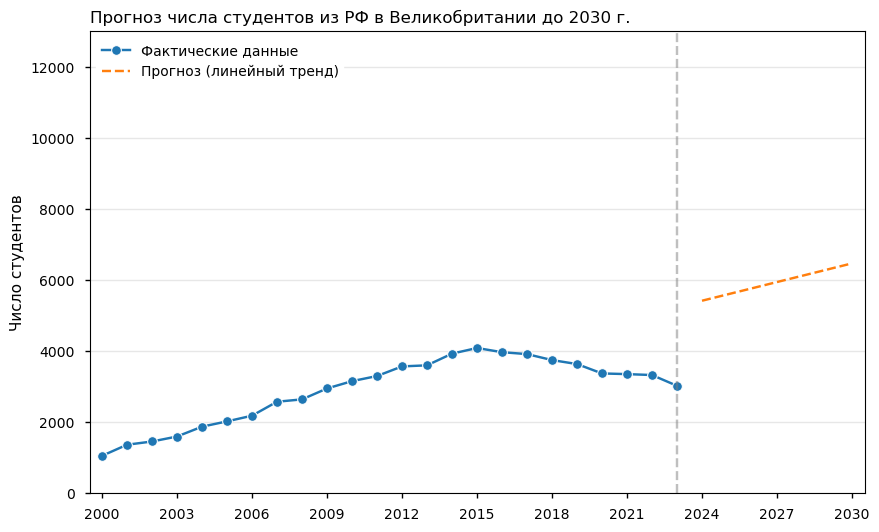

In [23]:
# Визуализация фактической и прогнозной динамики числа российских студентов в Великобритании

fig, ax=plt.subplots(figsize=(10,6))

sns.lineplot(data=df_gbr,
             x='Год', 
             y='United Kingdom',
             marker='o', 
             label='Фактические данные',
            ax=ax)

sns.lineplot(data=forecast_gbr,
             x='Год',
             y='Прогноз',
             linestyle='--',
             label='Прогноз (линейный тренд)',
            ax=ax)

ax.set_xlabel('')
ax.set_ylabel('Число студентов')
ax.set_title('Прогноз числа студентов из РФ в Великобритании до 2030 г.', loc='left')
ax.set_xlim(1999.5, 2030.5)
ax.set_ylim(0,13000)
ax.set_xticks(range(2000,2031,3))
ax.legend(loc='upper left', framealpha=1, edgecolor='white')
ax.axvline(2023, linestyle='--', color='gray', alpha=0.5)
ax.grid(axis='y', alpha=0.3)

plt.savefig('../visuals/05_forecast_gbr.png', dpi=150, bbox_inches='tight')

plt.show()

## Турция

In [24]:
# Подготовка данных по Турции

df_tur=df_pivot.drop(['Germany', 'United Kingdom'], axis=1).dropna().reset_index(drop=True)
df_tur['time']=df_tur['Год']-df_tur['Год'].min()
df_tur.head()

Страна,Год,Türkiye,time
0,2000,1004.0,0
1,2001,924.0,1
2,2002,846.0,2
3,2003,720.0,3
4,2004,662.0,4


In [25]:
# Выделение матрицы объект-признак и целевой переменной
X_tur=df_tur[['time']]
y_tur=df_tur['Türkiye']

# Разделение выборки на тренировочную и тестовую части
tur_train=int(len(df_tur)*0.8)
tur_test=len(df_tur)-tur_train

# Первые 80% данных на обучение модели
X_tur_train=df_tur[['time']][:tur_train]
y_tur_train=df_tur['Türkiye'][:tur_train]

# Другие 20% данных на тестирование модели
X_tur_test=df_tur[['time']][tur_train:]
y_tur_test=df_tur['Türkiye'][tur_train:]

# Обучение модели на тренировочных данных
model_tur=LinearRegression()
model_tur.fit(X_tur_train, y_tur_train)

LinearRegression()

In [26]:
# Проверка модели на тестовых данных
tur_test_pred=model_tur.predict(X_tur_test)
tur_test_pred

array([ 986.84210526, 1007.81578947, 1028.78947368, 1049.76315789,
       1070.73684211])

In [27]:
# Проверка качества модели

# Вычисление метрики MSE на тестовых данных
print(f'MSE: {mean_squared_error(y_tur_test, tur_test_pred)}')

# Вычисление метрики RMSE на тестовых данных (средняя ошибка прогноза)
print(f'RMSE: {mean_squared_error(y_tur_test, tur_test_pred) ** 0.5}')

# Вычисление ежегодного прироста и базового уровня
print(f'Ежегодный прирост: {model_tur.coef_[0]}',
      f'\nБазовый уровень: {model_tur.intercept_}')

MSE: 1046799.1930747923
RMSE: 1023.132050653674
Ежегодный прирост: 20.97368421052631 
Базовый уровень: 588.3421052631579


In [28]:
# Прогноз тренда мобильности для Турции с 2024 по 2030 год
last_time_tur=df_tur['time'].max()
future_tur=pd.DataFrame({'Год':[2024,2025,2026,2027,2028,2029,2030],
                         'time':range(last_time_tur + 1, last_time_tur + 8)})

X_tur_future=future_tur[['time']]
Y_tur_future=model_tur.predict(X_tur_future)
Y_tur_future

array([1091.71052632, 1112.68421053, 1133.65789474, 1154.63157895,
       1175.60526316, 1196.57894737, 1217.55263158])

In [29]:
# Таблица прогноза для Турции

forecast_tur=future_tur.drop('time', axis=1)
forecast_tur['Прогноз']=Y_tur_future.round().astype(int)
forecast_tur

,Год,Прогноз
0,2024,1092
1,2025,1113
2,2026,1134
3,2027,1155
4,2028,1176
5,2029,1197
6,2030,1218


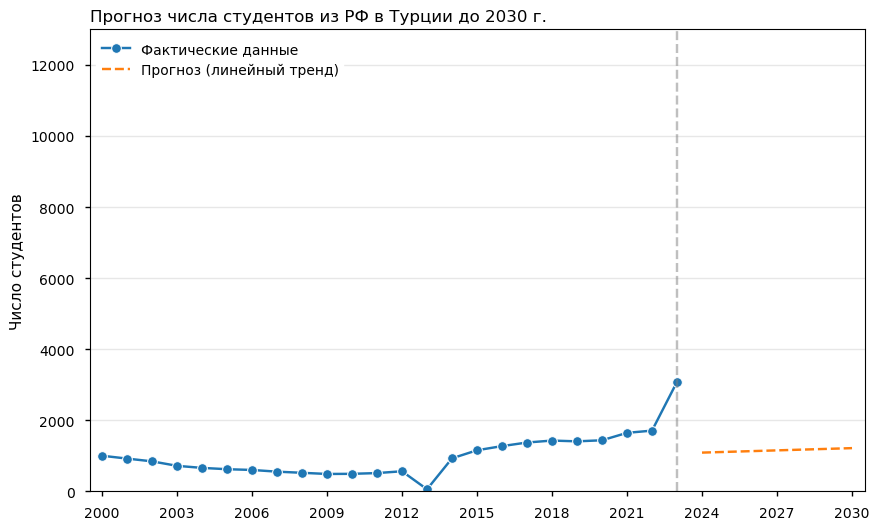

In [30]:
# Визуализация фактической и прогнозной динамики числа российских студентов в Турции

fig, ax=plt.subplots(figsize=(10,6))

sns.lineplot(data=df_tur,
             x='Год', 
             y='Türkiye',
             marker='o', 
             label='Фактические данные',
            ax=ax)

sns.lineplot(data=forecast_tur,
             x='Год',
             y='Прогноз',
             linestyle='--',
             label='Прогноз (линейный тренд)',
            ax=ax)

ax.set_xlabel('')
ax.set_ylabel('Число студентов')
ax.set_title('Прогноз числа студентов из РФ в Турции до 2030 г.', loc='left')
ax.set_xlim(1999.5, 2030.5)
ax.set_ylim(0,13000)
ax.set_xticks(range(2000,2031,3))
ax.legend(loc='upper left', framealpha=1, edgecolor='white')
ax.axvline(2023, linestyle='--', color='gray', alpha=0.5)
ax.grid(axis='y', alpha=0.3)

plt.savefig('../visuals/05_forecast_tur.png', dpi=150, bbox_inches='tight')

plt.show()

## Визуализация прогноза для Германии, Великобритании и Турции

Для более удобного сравнения графики для трех стран построены на одной фигуре.

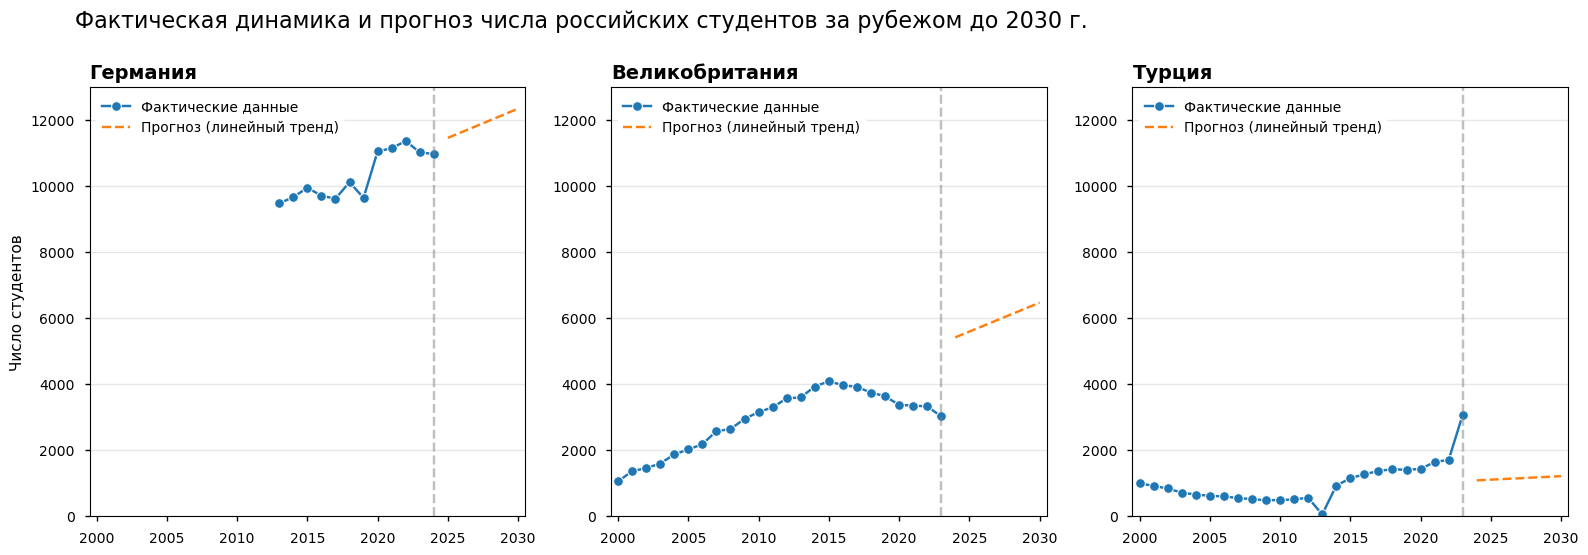

In [31]:
# Германия

fig, (ax1, ax2, ax3)=plt.subplots(1,3, figsize=(16,5.5))

sns.lineplot(data=df_deu,
             x='Год', 
             y='Germany',
             marker='o', 
             label='Фактические данные',
            ax=ax1)

sns.lineplot(data=forecast_deu,
             x='Год',
             y='Прогноз',
             linestyle='--',
             label='Прогноз (линейный тренд)',
            ax=ax1)

ax1.set_xlabel('')
ax1.set_ylabel('Число студентов')
ax1.set_title('Германия', 
              loc='left',
             fontsize=14,
             fontweight='bold')
ax1.set_xlim(1999.5, 2030.5)
ax1.set_ylim(0,13000)
ax1.set_xticks(range(2000,2031,5))
ax1.legend(loc='upper left', framealpha=1, edgecolor='white')
ax1.axvline(2024, linestyle='--', color='gray', alpha=0.5)
ax1.grid(axis='y', alpha=0.3)

# Великобритания

sns.lineplot(data=df_gbr,
             x='Год', 
             y='United Kingdom',
             marker='o', 
             label='Фактические данные',
            ax=ax2)

sns.lineplot(data=forecast_gbr,
             x='Год',
             y='Прогноз',
             linestyle='--',
             label='Прогноз (линейный тренд)',
            ax=ax2)

ax2.set_xlabel('')
ax2.set_ylabel('')
ax2.set_title('Великобритания', 
              loc='left',
             fontsize=14,
             fontweight='bold')
ax2.set_xlim(1999.5, 2030.5)
ax2.set_ylim(0,13000)
ax2.set_xticks(range(2000,2031,5))
ax2.legend(loc='upper left', framealpha=1, edgecolor='white')
ax2.axvline(2023, linestyle='--', color='gray', alpha=0.5)
ax2.grid(axis='y', alpha=0.3)

# Турция

sns.lineplot(data=df_tur,
             x='Год', 
             y='Türkiye',
             marker='o', 
             label='Фактические данные',
            ax=ax3)

sns.lineplot(data=forecast_tur,
             x='Год',
             y='Прогноз',
             linestyle='--',
             label='Прогноз (линейный тренд)',
            ax=ax3)

ax3.set_xlabel('')
ax3.set_ylabel('')
ax3.set_title('Турция',
              loc='left', 
              fontsize=14,
             fontweight='bold')
ax3.set_xlim(1999.5, 2030.5)
ax3.set_ylim(0,13000)
ax3.set_xticks(range(2000,2031,5))
ax3.legend(loc='upper left', framealpha=1, edgecolor='white')
ax3.axvline(2023, linestyle='--', color='gray', alpha=0.5)
ax3.grid(axis='y', alpha=0.3)

plt.suptitle('Фактическая динамика и прогноз числа российских студентов за рубежом до 2030 г.',
             fontsize=16, x=0.05, y=1.001, ha='left')

plt.tight_layout()

plt.savefig('../visuals/05_forecast_student_mobility.png', dpi=150, bbox_inches='tight')

plt.show()

In [32]:
## Общая таблица прогноза для Германии, Великобритании и Турции

forecast_deu=forecast_deu.rename(columns={'Прогноз': 'Германия'})
forecast_gbr=forecast_gbr.rename(columns={'Прогноз': 'Великобритания'})
forecast_tur=forecast_tur.rename(columns={'Прогноз': 'Турция'})
forecast=(forecast_deu.merge(forecast_gbr, on='Год', how='outer')).merge(forecast_tur, on='Год', how='outer')
forecast.to_excel('../data/processed/forecast.xlsx', index=False)

print('Таблица прогноза числа студентов для Германии, Великобритани и Турции:')
print('=' * 70)
print(forecast)


Таблица прогноза числа студентов для Германии, Великобритани и Турции:
    Год  Германия  Великобритания  Турция
0  2024       NaN            5422    1092
1  2025   11463.0            5597    1113
2  2026   11640.0            5772    1134
3  2027   11817.0            5948    1155
4  2028   11994.0            6123    1176
5  2029   12171.0            6298    1197
6  2030   12349.0            6473    1218


## Основные результаты прогнозирования:
- Визуализация фактических данных и сглаженный тренд показывают различный характер динамики числа российских студентов в Германии, Великобритании и Турции.
- В Германии наблюдается долгосрочный рост числа студентов с последующей стабилизацией показателя на высоком уровне. В Великобритании после периода роста до середины 2010-х гг. фиксируется устойчивое снижение числа студентов. В Турции динамика имеет противоположный характер: после длительного снижения начинается постепенное увеличение числа студентов из России.
- Для Германии линейная модель прогнозирует продолжение умеренного роста числа студентов. Для Великобритании модель также прогнозирует рост показателя, в то время как фактические данные за последние годы показывают тренд на снижение числа российских студентов в стране. Прогноз для Турции говорит о медленном росте образовательного потока. 
- Построенная модель линейной регрессии показывает приемлемое качество прогноза для Германии, но низкую точность для Великобритании и Турции из-за нелинейного характера динамики числа студентов в этих странах.
- Линейная модель экстраполирует существующий тренд на ближайшие годы, для которых строится прогноз. Для повышения точности прогнозирования необходимо применять более сложные модели и учитывать такие факторы, как внешнеполитические условия, санкции, визовая политика, доступность образовательных программ и другие.

# Ключевые результаты проекта и рекомендации
- Общая динамика международной мобильности российских студентов положительная – интерес и готовность к обучению за рубежом высокие. С 2018 гг. динамика становится более изменчивой, усиливаются годовые колебания, а с 2023 г. число студентов из России за рубежом заметно снижается. 
- С середины 2010-х гг. Азия (CAGR=6,1%) начинает значительно опережать Европу (CAGR=-2,1%) по темпу роста числа студентов из России, что может быть связано с изменившейся геополитической ситуацией и эффектом низкой базы. При этом доля стран Азии в структуре мобильности по-прежнему остается существенно ниже доли стран Европы. 
- Устойчивая региональная структура мобильности с преобладанием европейских направлений и ограниченной диверсификацией. Изменения за 25 лет незначительные, даже несмотря на снижение темпов роста числа студентов в Европе. Доля стран Европы в общем потоке выросла с 70,2% в 2000–2012 гг. до 71,7% в 2013–2024 гг. Несмотря на ускоренный рост отдельных азиатских направлений, доля стран Азии сократилась с 22,8% до 16,5%, что связано с более высоким исходным уровнем и масштабом образовательных потоков в Европу.
- Анализ структуры мобильности по типу образовательных направлений для десяти ведущих стран Европы и Азии показывает, что чаще всего студенты выбирали для обучения глобальные образовательные центры. Доля глобальных образовательных центров выросла с 45% в 2000–2012 гг. до 55% в 2013–2024 гг., доля региональных центров увеличилась с 27% до 31%. Доля стран постсоветского пространства сократилась с 28% до 14%.
- Концентрация мобильности по странам умеренная: несмотря на то что 10 стран принимают почти две трети студентов, география мобильности остается широкой (110 стран) с относительно равномерным распределением студентов по остальным странам. Наблюдается тенденция к усилению концентрации (HHI за 25 лет вырос на 34% c 0,073 до 0,098).
- Германия – абсолютный лидер по числу студентов из России (доля в общем потоке 13%) и наиболее стабильное направление (CV=0,07) среди ведущих европейских и азиатских стран. Наименее стабильные направления среди ведущих стран Европы и Азии – Чехия (CV=0,82), Киргизия (CV=0,62), Турция (CV=0,62) и Республика Корея (CV=0,75). 
- Среди стран с существенным абсолютным приростом входящей мобильности из России Чехия (CAGR=20,3%), Италия (15,2%), Армения (11,3%) и Республика Корея (12,7%) показывают наиболее высокие среднегодовые темпы роста за весь период с 2000 по 2024 г., но актуальные лидеры роста в Европе и Азии (2013-2024 гг.) – Турция (CAGR=48,3%), Словакия (31,2%), Сербия (27,3%), Словения (25,1%), Венгрия (12,5%), Узбекистан (19,3%), Республика Корея (14,2%).
- Качество образования, стоимость жизни и государственные расходы на высшее образование не объясняют различия в распределении российских студентов между странами – для оценки трендов мобильности необходимо учитывать такие факторы, как внешнеполитические условия, санкции, визовая политика, доступность образовательных программ и другие.
- При сохранении текущих тенденций возможен умеренный рост потока студентов в Германию в ближайшие годы (177 человек в год согласно линейной модели). Модель экстраполирует текущий тренд на ближайшие годы и не учитывает влияние внешних факторов.

**Рекомендации учреждениям высшего образования:**

1.	Анализ показывает, что диверсификация направлений остается ограниченной. Рекомендуется развивать образовательные связи со странами Азии, Африки и Латинской Америки. 
2.	Расширять сотрудничество с региональными образовательными центрами и растущими направлениями (Турция, Республика Корея, страны Центральной Азии).
3.	Применяя метрики CAGR и CV, проводить мониторинг наиболее активно растущих направлений. При планировании международных образовательных программ оценивать стабильность потоков и возможные риски.
4.	В рамках факторного анализа мобильности учитывать геополитические риски, санкции, визовую политику, стоимость обучения и наличие стипендиальных программ.

# Следующие шаги
- Работа с дополнительными данными, которых нет в базе данных ЮНЕСКО (например, по Китаю).
- Анализ потоков студентов в Северную Америку. 
- Расчет CAGR для отдельных стран Европы и Азии внутри более коротких периодов, чтобы выяснить лидеров по росту в Европе и Азии.
- Анализ дополнительных факторов (внешнеполитические условия, санкции, визовая политика, доступность образовательных программ и т.д.), и их учет при прогнозировании.
- Применение более сложных моделей прогнозирования.